# **Training of the Teacher Models (CovidCNN($T_1$), DEEPCovid($T_2$),CovidVGG16($T_3$)) and their corresponding Student models (CovidCNN($S_1$),DEEPCovid($S_2$), CovidVGG16($S_3$))**

In [1]:
import tensorflow as tf
tf.config.list_physical_devices("GPU")

2026-01-09 11:36:29.325284: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 11:36:29.355599: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-09 11:36:29.355625: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-09 11:36:29.355645: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 11:36:29.361345: I tensorflow/core/platform/cpu_feature_g

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]

## **Importing Relevant Libraries**

In [2]:
import pandas as pd
import random
import cv2
import os.path
from PIL import Image
from skimage.io import imread, imsave, imshow, show, imread_collection, imshow_collection
import os
import glob
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow import keras
import logging
tf.config.set_visible_devices([], 'GPU')
from sklearn import preprocessing
tf.get_logger().setLevel(logging.ERROR)
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from tqdm.notebook import tqdm
import time
from sklearn.preprocessing import MinMaxScaler
import tensorflow_federated as tff

## **Datasets Proprocessing**

In [3]:
IMAGE_SIZE = 200
class ImageDataProcessor:
    def __init__(self):
        pass

    def process_image(self, folderpath, prefix, fileExtension, binary_label):
        folder_path = folderpath
        new_prefix = prefix

        img_names = []
        with os.scandir(folder_path) as dirs:
            for entry in dirs:
                img_names.append(entry.name)
        scaler = MinMaxScaler()
        all_features = []

        for img in img_names:
            path = folder_path + img
            cv_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            cv_img2 = cv2.resize(cv_img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
            # Normalize pixel values
            normalized_img = cv_img2 / 255.0  # Scale pixel values to [0, 1]

            # Reshape the normalized image into a feature vector
            nFeatures = (normalized_img.shape[0] * normalized_img.shape[1])
            features = np.reshape(normalized_img, nFeatures)

            all_features.append(features)

        imgs_df = pd.DataFrame(np.array(all_features), index=img_names)
        if binary_label == 0:
            imgs_df['class_label'] = np.zeros((imgs_df.shape[0]), dtype=int)
        else:
            imgs_df['class_label'] = np.ones((imgs_df.shape[0]), dtype=int)
        return imgs_df

    def process_dataset(self, ct_covid_features_df, ct_noncovid_features_df, num_iterations=100):
        cvd_imgs = [ct_noncovid_features_df, ct_covid_features_df]
        cvd_imgs_dataset = pd.concat(cvd_imgs)

        for _ in range(num_iterations):
            cvd_imgs_dataset = cvd_imgs_dataset.sample(frac=1)

        input_data_x = cvd_imgs_dataset.iloc[:, :-1].to_numpy().reshape((cvd_imgs_dataset.shape[0], IMAGE_SIZE, IMAGE_SIZE, 1))

        label_encoder = preprocessing.LabelEncoder()
        cvd_imgs_dataset['output_encode'] = label_encoder.fit_transform(cvd_imgs_dataset['class_label'])
        cvd_imgs_dataset = pd.get_dummies(cvd_imgs_dataset, columns=['output_encode'])
        output_label_y = np.array(cvd_imgs_dataset[['output_encode_0', 'output_encode_1']])

        return input_data_x, output_label_y


In [4]:
pwd

'/home/maxwellsam/Compression_Model_FL_MTKD'

### **Data Source**

- https://www.kaggle.com/datasets/luisblanche/covidct (dataset3)
- https://www.kaggle.com/datasets/maedemaftouni/large-covid19-ct-slice-dataset (dataset2)

- https://www.kaggle.com/datasets/mehradaria/covid19-lung-ct-scans (Dataset1)
- https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset (Dataset1)

#### **Loading and Preprocessing Dataset 1**

In [5]:
# Example usage:
path1 = '/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset1/CT_COVID/'
prefix1 = 'ct_covid'
path2 = '/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset1/CT_NonCOVID/'
prefix2 = 'ct_noncovid'

processor = ImageDataProcessor()

ct_covid_features_df = processor.process_image(path1, prefix1, 'png', 1)  # 1--> covid-19 positive
ct_noncovid_features_df = processor.process_image(path2, prefix2, 'png', 0)  # 0 ---> covid-19 negative

input_data_x, output_label_y = processor.process_dataset(ct_covid_features_df, ct_noncovid_features_df)

print('Input_x Data Shape: \n{0}'.format(input_data_x.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y.shape))

Input_x Data Shape: 
(4649, 200, 200, 1)
Output_y Data Shape: 
(4649, 2)


#### **Loading and Preprocessing Dataset 2**

In [7]:
# Example usage:
path1 = '/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset2/COVID/'
prefix1 = 'ct_covid'
path2 = '/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset2/Non_COVID/'
prefix2 = 'ct_noncovid'

processor = ImageDataProcessor()

ct_covid_features_df = processor.process_image(path1, prefix1, 'png', 1)  # 1--> covid-19 positive
ct_noncovid_features_df = processor.process_image(path2, prefix2, 'png', 0)  # 0 ---> covid-19 negative

input_data_x_2, output_label_y_2 = processor.process_dataset(ct_covid_features_df, ct_noncovid_features_df)

print('Input_x Data Shape: \n{0}'.format(input_data_x_2.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_2.shape))

Input_x Data Shape: 
(13980, 200, 200, 1)
Output_y Data Shape: 
(13980, 2)


#### **Loading and Preprocessing Dataset 3**

In [11]:
# Example usage:
path1 = '/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset3/COVID/images/'
prefix1 = 'ct_covid'
path2 = '/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset3/Non_COVID/images/'
prefix2 = 'ct_noncovid'

processor = ImageDataProcessor()

ct_covid_features_df = processor.process_image(path1, prefix1, 'png', 1)  # 1--> covid-19 positive
ct_noncovid_features_df = processor.process_image(path2, prefix2, 'png', 0)  # 0 ---> covid-19 negative

input_data_x_3, output_label_y_3 = processor.process_dataset(ct_covid_features_df, ct_noncovid_features_df)

print('Input_x Data Shape: \n{0}'.format(input_data_x_3.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_3.shape))

Input_x Data Shape: 
(13808, 200, 200, 1)
Output_y Data Shape: 
(13808, 2)


### **Saving Datasets as Numpy Arrays for later loading**:

In [ ]:
# Save the array to a file
np.save('Dataset1_input.npy', input_data_x)
np.save('Dataset1_output.npy', output_label_y)
np.save('Dataset2_input.npy', input_data_x_2)
np.save('Dataset2_output.npy', output_label_y_2)
np.save('Dataset3_input.npy', input_data_x_3)
np.save('Dataset3_output.npy', output_label_y_3)

###  **Loading Saved and already Preprocessed Datasets**:

In [12]:
# # Load the array from the file
input_data_x_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset1/Dataset1_input.npy')
output_label_y_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset1/Dataset1_output.npy')
input_data_x_2_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset2/Dataset2_input.npy')
output_label_y_2_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset2/Dataset2_output.npy')
input_data_x_3_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset3/Dataset3_input.npy')
output_label_y_3_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset3/Dataset3_output.npy')

# Now loaded_arr contains the array loaded from the file
print('------------------ DATASET 1 ---------------------')
print('Input_x Data Shape: \n{0}'.format(input_data_x_load.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_load.shape))

print('------------------ DATASET 2 ---------------------')
print('Input_x Data Shape: \n{0}'.format(input_data_x_2_load.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_2_load.shape))

print('------------------ DATASET 3 ---------------------')
print('Input_x Data Shape: \n{0}'.format(input_data_x_3_load.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_3_load.shape))

------------------ DATASET 1 ---------------------
Input_x Data Shape: 
(4649, 200, 200, 1)
Output_y Data Shape: 
(4649, 2)
------------------ DATASET 2 ---------------------
Input_x Data Shape: 
(13980, 200, 200, 1)
Output_y Data Shape: 
(13980, 2)
------------------ DATASET 3 ---------------------
Input_x Data Shape: 
(13808, 200, 200, 1)
Output_y Data Shape: 
(13808, 2)


## **Training Teacher Models on the respective datasets to train their corresponding student models via Knowledge distillation**

### **Creating Training and Test Dataset for each teacher and student model training**



*   For Dataset 1 ($H_1$) 2000 out of 4649 is resrved for teacher model ($T_1$) Training and student model ($S_1$)knowledge distillation the remaining are used for Federated Learning Training.
*   For Dataset 2 ($H_2$) 5200 out of 14486 is resrved for teacher model ($T_2$) Training and student model ($S_2$)knowledge distillation the remaining are used for Federated Learning Training.
*   For Dataset 3 ($H_3$) 960 out of 2540 is resrved for teacher model ($T_3$) Training and student model ($S_2$)knowledge distillation the remaining are used for Federated Learning Training



In [13]:
from sklearn.model_selection import train_test_split


train_features_dataset1, test_features_dataset1, train_labels_dataset1, test_labels_dataset1 = train_test_split(
    input_data_x_load[0:2500,:], output_label_y_load[0:2500,:], test_size=.20, random_state=25)

train_features_dataset2, test_features_dataset2, train_labels_dataset2, test_labels_dataset2 = train_test_split(
    input_data_x_2_load[0:6500,:], output_label_y_2_load[0:6500,:], test_size=.20, random_state=25)

train_features_dataset3, test_features_dataset3, train_labels_dataset3, test_labels_dataset3 = train_test_split(
    input_data_x_3_load[0:1200,:], output_label_y_3_load[0:1200,:], test_size=.20, random_state=25)

print('------ Training Teacher Models----------')
print('client 1 teacher dataset: ',train_features_dataset1.shape, test_features_dataset1.shape, train_labels_dataset1.shape, test_labels_dataset1.shape)
print('client 2 teacher dataset: ',train_features_dataset2.shape, test_features_dataset2.shape, train_labels_dataset2.shape, test_labels_dataset2.shape)
print('client 3 teacher dataset: ',train_features_dataset3.shape, test_features_dataset3.shape, train_labels_dataset3.shape, test_labels_dataset3.shape)

------ Training Teacher Models----------
client 1 teacher dataset:  (2000, 200, 200, 1) (500, 200, 200, 1) (2000, 2) (500, 2)
client 2 teacher dataset:  (5200, 200, 200, 1) (1300, 200, 200, 1) (5200, 2) (1300, 2)
client 3 teacher dataset:  (960, 200, 200, 1) (240, 200, 200, 1) (960, 2) (240, 2)


#### **Data Augmentation on Dataset to train Teacher Models**

In [14]:
from tensorflow import keras
image_size_ = 200
data_augmentation = keras.Sequential(
    [
        tf.keras.layers.Normalization(),
        tf.keras.layers.Resizing(image_size_, image_size_),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor=0.02),
        tf.keras.layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(train_features_dataset1)

### **Training Teacher Model (CovidCNN($T_1$))**

In [24]:
import seaborn as sns
def getCorrectLabel(x):
        if x == 0:
            return 'Non-Covid'
        if x == 1:
            return 'Covid'

def D1_to_D2(y_pred):
    y_true = {'y_true':[i[0] for i in y_pred]}
    y_true_df = pd.DataFrame(y_true)
    y_true_df = pd.get_dummies(y_true_df, columns =['y_true'])
    output_label_y = np.array(y_true_df[y_true_df.columns])
    return output_label_y

def getModelEvaluation(model, test_features_,test_labels_):
    predicted_labels = model.predict(np.stack(test_features_))
    df = pd.DataFrame(predicted_labels)
    df['Predicted_Labels'] = np.array(df.iloc[:,:2]).argmax(axis =1)
    df['Predicted_Labels'] = df['Predicted_Labels'].apply(getCorrectLabel)
    if (test_labels_.shape[1]==2):
        df['Actual_Labels'] = test_labels_[:,:2].argmax(axis = 1)
    else:
        df['Actual_Labels'] = D1_to_D2(test_labels_)[:,:2].argmax(axis = 1)
    df['Actual_Labels'] = df['Actual_Labels'].apply(getCorrectLabel)
    cm = pd.crosstab(df.Predicted_Labels, df.Actual_Labels)
    fig = plt.figure(figsize=(20,5))
    ax1 = plt.subplot(121)
    sns.heatmap(cm,annot = True,cmap='Blues')
    ax1.set_title('')
    # Saving the figure.
    plt.savefig("test_Confusion_Matrix_with_i.jpg")
    plt.show()
    plt.close()

    test_labels__ = [i.argmax() for i in test_labels_]
    pred_list = [i.argmax() for i in predicted_labels]
    count = 0
    for i in range(test_labels_.shape[0]):
        if int(test_labels__[i]) == int(pred_list[i]):
            count+=1
    print("test accuracy = " + str((count/test_labels_.shape[0])*100)+'%')
    print('-------------------------------------------------------------------------------------------------')
    print('Model Metrics')
    # getting model predictions
    #test_predictions,_ = model.predict((x_test,y_test),20)
    predictions = pd.DataFrame(predicted_labels)#, columns=labels_ohe_names.columns
    predictions = list(predictions.idxmax(axis=1))
    test_labels__ = [i.argmax() for i in test_labels_]

    # evaluate model performance
    #import model_evaluation_utils_ as meu
    meu.get_metrics(true_labels=test_labels__,
                    predicted_labels=predictions)
def evaluateModel_loss(history):
    print()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.legend(['Training loss','Validation loss'], loc = 'upper left')
    plt.savefig("Training_validation_loss_with_i.jpg")
    plt.show()
    plt.close()
    #plt.show()
    print()
def evaluateModel_accuracy(history):
    print()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Training and Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('epochs')
    plt.legend(['Training Accuracy','Validation Accuracy'], loc = 'upper left')
    #plt.show()
    plt.savefig("Training_validation_accuracy_with_i.jpg")
    plt.show()
    plt.close()
    print()

def compile_model(model, loss_, learningRate, metrics_):
    '''
    def compile_model(DNN, loss_, learningRate, metrics_):
    DNN: the model
    loss_: the loss function
    learningRate: learning rate
    metrics_: metrics of interest [mse', 'mae'] #since a regression model
    '''
    model.compile(tf.keras.optimizers.Adam(learning_rate=learningRate),loss=loss_,metrics=metrics_)
    return model

def CNN_Mod(model, num_hl, hl_list,hl_conv_activation, ol_activation, dropout_val, inputShape,filters_,kernel_size_,stride_poolSize):
    '''
    CNN_Mod(model, num_hl, hl_list,hl_conv_activation, ol_activation, dropout_val, inputShape,filters_,kernel_size_,stride_poolSize):
        model = CNN Model
        num_hl = number of hidden layers
        hl_list = list of hidden layers
        hl_activation = hidden layer activation function
        out_activation = output layer activation function
        dropout_val = Dropout value
        inputShape = shape of input layer
        filters_ = filter size of Conv layer
        kernel_size_ = size of kernel (x,x)
        strides_poolSize = strides and max_pool_szie
    '''
    assert(num_hl == len(hl_list))
    assert(num_hl == len(dropout_val))
    inputs = tf.keras.layers.Input(shape=inputShape)
    # Augment data.
    augmented = data_augmentation(inputs)
    initializer = tf.keras.initializers.GlorotNormal(seed=0)
    #connnnvolultion layer 1 with Map-pooling
    conv_layer_1 = tf.keras.layers.Conv2D(filters = filters_,kernel_size = kernel_size_,strides = stride_poolSize, activation = hl_conv_activation)(augmented)#(augmented)
    conv_layer_1_max_pool = tf.keras.layers.MaxPool2D(strides=stride_poolSize)(conv_layer_1)
    x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(conv_layer_1_max_pool)

    #connnnvolultion layer 1 with Map-pooling
    conv_layer_2 = tf.keras.layers.Conv2D(filters = filters_,kernel_size = kernel_size_,strides = stride_poolSize, activation = hl_conv_activation)(x1)
    conv_layer_2_max_pool = tf.keras.layers.MaxPool2D(strides=stride_poolSize)(conv_layer_2)
    x2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(conv_layer_2_max_pool)

    flatten_layer = tf.keras.layers.Flatten()(x2)

    dense_layers = tf.keras.layers.Dense(kernel_initializer=initializer, units = hl_list[0], activation = hl_conv_activation)(flatten_layer)
    dense_layers = tf.keras.layers.Dropout(dropout_val[0])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)           # Batch normalization layer

    dense_layers = tf.keras.layers.Dense(kernel_initializer=initializer, units = hl_list[1], activation = hl_conv_activation)(dense_layers)
    dense_layers = tf.keras.layers.Dropout(dropout_val[1])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)

    dense_layers = tf.keras.layers.Dense(kernel_initializer=initializer, units = hl_list[2], activation = hl_conv_activation)(dense_layers)
    dense_layers = tf.keras.layers.Dropout(dropout_val[2])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)

    dense_layers = tf.keras.layers.Dense(kernel_initializer=initializer, units = hl_list[3], activation = hl_conv_activation)(dense_layers)
    dense_layers = tf.keras.layers.Dropout(dropout_val[3])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)

    logits = tf.keras.layers.Dense(units = 2, activation = ol_activation)(dense_layers)

    # Create the Keras model.
    model = tf.keras.Model(inputs=inputs,outputs=logits)
    model = compile_model(model, 'categorical_crossentropy',0.001,['accuracy'])#0621475226496656
    return model

def buildModel(model, val_split_size, batch_size_,numEpochs, patience_, monitor_, mode):
  '''
  def buildModel(DNN, val_split_size, batch_size_,numEpochs, patience_, monitor_, mode):
    DNN: DNN which the model
    val_split_size: the validation split)
    batch_size_: batch_size
    numEpochs: number of epochs
    patience_: patience of call back
    monitor_: monitor (objective of callback)
    mode: mode (min, max, auto)
  '''
  history = model.fit(
    train_features_dataset1,
    train_labels_dataset1,
    validation_split = val_split_size,
    batch_size = batch_size_,
    epochs = numEpochs,
    callbacks = [
      tf.keras.callbacks.EarlyStopping(monitor= monitor_,patience=patience_,verbose=1,mode=mode),#monitoring loss mode should be min [---val_acc--]
    ]
    )

  return history

In [16]:
teacher_model  = tf.keras.models.Sequential()
teacher_model  = CNN_Mod(teacher_model, 4, [362, 184, 78, 12],'relu','softmax',[0.00,0.35,0.0,0.00],(IMAGE_SIZE,IMAGE_SIZE,1),116,8,2)
history = buildModel(teacher_model,0.20,32,150,10, "val_loss", "min")
# # Load the Keras model
# teacher_model  = tf.keras.models.Sequential()
# teacher_model  = CNN_Mod(teacher_model, 4, [2756, 1776, 620, 152],'relu','softmax',[0.35,0.00,0.00,0.35],(IMAGE_SIZE,IMAGE_SIZE,1),214,5,3)
# history = buildModel(teacher_model,0.20,128,150,10, "val_loss", "min")

Epoch 1/150


2026-01-09 11:52:54.230095: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x33243130 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-01-09 11:52:54.230168: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-01-09 11:52:54.273842: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-09 11:52:54.413741: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-01-09 11:52:54.415346: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2026-01-09 11:52:54.415549: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


 1/50 [..............................] - ETA: 1:26 - loss: 0.7002 - accuracy: 0.5938

2026-01-09 11:52:54.459074: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2026-01-09 11:52:54.581473: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2026-01-09 11:52:54.584705: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


 5/50 [==>...........................] - ETA: 9s - loss: 0.8993 - accuracy: 0.5875

2026-01-09 11:52:55.204984: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


50/50 [==============================] - 13s 228ms/step - loss: 0.7175 - accuracy: 0.6269 - val_loss: 0.6201 - val_accuracy: 0.6575
Epoch 2/150
50/50 [==============================] - 11s 226ms/step - loss: 0.6120 - accuracy: 0.6981 - val_loss: 0.5888 - val_accuracy: 0.6950
Epoch 3/150
50/50 [==============================] - 11s 220ms/step - loss: 0.5657 - accuracy: 0.7125 - val_loss: 0.5820 - val_accuracy: 0.6625
Epoch 4/150
50/50 [==============================] - 11s 219ms/step - loss: 0.5457 - accuracy: 0.7219 - val_loss: 0.5619 - val_accuracy: 0.6900
Epoch 5/150
50/50 [==============================] - 11s 214ms/step - loss: 0.5044 - accuracy: 0.7412 - val_loss: 0.5029 - val_accuracy: 0.7500
Epoch 6/150
50/50 [==============================] - 11s 216ms/step - loss: 0.5167 - accuracy: 0.7450 - val_loss: 0.5571 - val_accuracy: 0.7350
Epoch 7/150
50/50 [==============================] - 11s 220ms/step - loss: 0.4900 - accuracy: 0.7613 - val_loss: 0.5563 - val_accuracy: 0.7250
Epoc

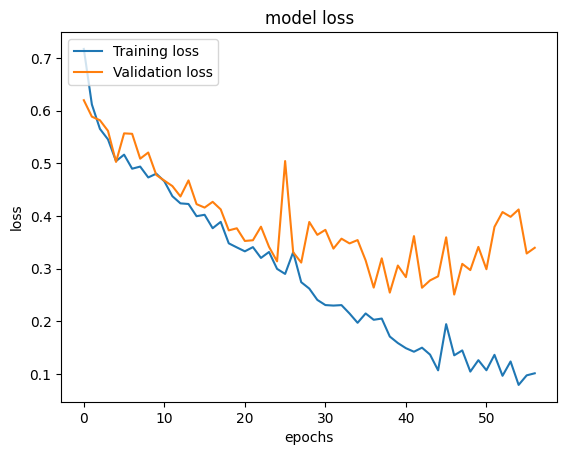

In [17]:
evaluateModel_loss(history)

In [18]:
teacher_model.save('teacher_CNN_model.h5')
teacher_model_cnn = tf.keras.models.load_model('teacher_CNN_model.h5')

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [23]:
from sklearn import metrics
import numpy as np

# Define a dummy module-like class to handle the 'meu' alias
class ModelEvaluationUtils:
    @staticmethod
    def get_metrics(true_labels, predicted_labels):
        print('Accuracy:', np.round(metrics.accuracy_score(true_labels, predicted_labels), 4))
        print('Precision:', np.round(metrics.precision_score(true_labels, predicted_labels, average='weighted'), 4))
        print('Recall:', np.round(metrics.recall_score(true_labels, predicted_labels, average='weighted'), 4))
        print('F1 Score:', np.round(metrics.f1_score(true_labels, predicted_labels, average='weighted'), 4))

# Create the alias 'meu' so your existing code works
meu = ModelEvaluationUtils()

In [22]:
import os
print(os.listdir('.'))

['test_Confusion_Matrix_with_i.jpg', 'data', '.ipynb_checkpoints', 'Teacher_Student_KD.ipynb', 'teacher_CNN_model.h5', 'FL_MTKD_with_compression.ipynb', 'Training_validation_loss_with_i.jpg']


--------------------- Teacher Model Evaluation -----------------------------------------
16/16 [==============================] - 1s 71ms/step


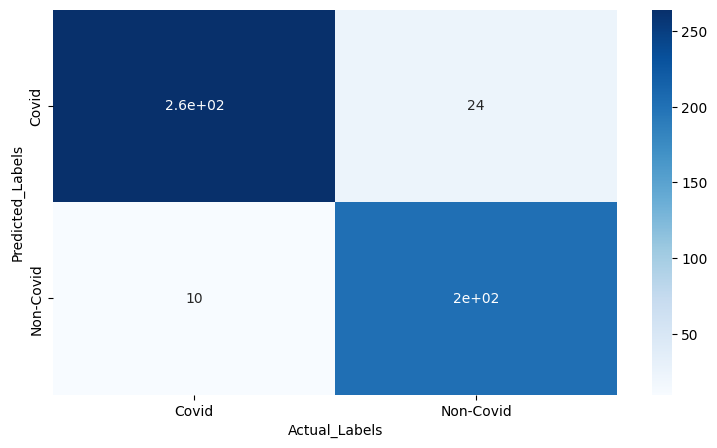

test accuracy = 93.2%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.932
Precision: 0.933
Recall: 0.932
F1 Score: 0.9318


In [25]:
print('--------------------- Teacher Model Evaluation -----------------------------------------')
getModelEvaluation(teacher_model_cnn,test_features_dataset1,test_labels_dataset1)

### **Training Teacher Model (Deep-COVID ($T_2$))**
M. Ghaderzadeh, F. Asadi, R. Jafari, D. Bashash, H. Abolghasemi, and M. Aria.Deep convolutional neural network–based computer-aided detection system for covid-19 using multiple lung scans: Design and implementation study. J Med Internet Res, 23:e27468, 2021,4.
http://www.ncbi.nlm.nih.gov/pubmed/33848973


In [26]:
import os
import random
import numpy as np
import math
import itertools

SEED = 7
os.environ['PYTHONHASHSEED']=str(SEED)
np.random.seed(SEED)
random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
import tensorflow.keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Activation, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers.experimental import preprocessing
import tensorflow.keras.backend as K

from tensorflow.keras.applications import NASNetLarge
NETWORK = NASNetLarge

#from kaggle_datasets import KaggleDatasets

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, mean_squared_error, classification_report


import re
import imageio
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
%matplotlib inline
try:
    tpu = None
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Device:', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)

    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()
print('Number of replicas:', strategy.num_replicas_in_sync)

print("Tensorflow version ", tf.__version__)


Number of replicas: 1
Tensorflow version  2.14.1


In [27]:
from tensorflow.keras.callbacks import Callback
class CosineAnnealingScheduler(Callback):

    def __init__(self, T_max, eta_max, eta_min=0, verbose=0):
        super(CosineAnnealingScheduler, self).__init__()
        self.T_max = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self.model.optimizer, 'lr'):
            raise ValueError('Optimizer must have a "lr" attribute.')
        lr = self.eta_min + (self.eta_max - self.eta_min) * (1 + math.cos(math.pi * epoch / self.T_max)) / 2
        K.set_value(self.model.optimizer.lr, lr)
        if self.verbose > 0:
            print('\nEpoch %05d: CosineAnnealingScheduler setting learning '
                  'rate to %s.' % (epoch + 1, lr))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = K.get_value(self.model.optimizer.lr)

image_size = 200
img_augmentation = keras.Sequential(
    [
        tf.keras.layers.Normalization(),
        tf.keras.layers.Resizing(image_size, image_size),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor=0.02),
        tf.keras.layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="Augmentation",
)
img_augmentation.layers[0].adapt(train_features_dataset1)

In [28]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
tf.config.optimizer.set_jit(True)

# dataset_id1 = 'covid19-lung-ct-scans'
# #GCS_PATH1 = KaggleDatasets().get_gcs_path(dataset_id1)
BATCH_SIZE = 128 * strategy.num_replicas_in_sync

CLASSES = ['COVID-19', 'Non-COVID-19']
NUM_CLASSES = len(CLASSES)
IMAGE_SIZE_ = [IMAGE_SIZE, IMAGE_SIZE]#224, 224
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)#224, 224, 3
LOSS = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

METRICS = ['accuracy']

Epochs = 50
Early_Stop = 15
OPTIMIZER = tensorflow.keras.optimizers.legacy.Adam(lr = 1e-2, decay = 1e-4)

Fine_Tune_Epochs = 100
Fine_Tune_Early_Stop = 20
Fine_Tune_OPTIMIZER = tensorflow.keras.optimizers.legacy.Adam(lr = 1e-3, decay = 1e-6)
Fine_Tune_filepath = "Best-Model-FT.h5"

Callbacks = [
    CosineAnnealingScheduler(Epochs, 1e-3, 1e-6),
    EarlyStopping(monitor='val_accuracy', patience=Early_Stop, mode='auto', min_delta=0.00001, verbose=2, restore_best_weights=True)]

FT_Callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, verbose=2, mode='min', min_delta=0.0001, cooldown=1, min_lr=1e-6),
    ModelCheckpoint(Fine_Tune_filepath, monitor='val_accuracy', verbose=2, save_best_only=True, save_weights_only=False, mode='max'),
    EarlyStopping(monitor='val_loss', patience=Fine_Tune_Early_Stop, mode='auto', min_delta=0.00001, verbose=2, restore_best_weights=True)]

from tensorflow.keras.layers import Lambda
input_tensor = Input(shape=input_shape)
input_rgb = Lambda(lambda x: K.repeat_elements(x, 3, axis=-1))(input_tensor)

def build_model(OPTIMIZER, LOSS, METRICS):
    model = None
    inputs = layers.Input(shape=input_shape)
    x = img_augmentation(inputs)
    baseModel = keras.applications.NASNetLarge(
    #input_shape=input_shape,
    include_top=False,
    weights="imagenet",
    input_tensor=input_rgb,
    pooling='avg',
    classifier_activation="softmax",
)
    #baseModel = NETWORK(include_top=False, input_tensor=x, weights="imagenet", pooling ='avg')

    baseModel.trainable = False

    x = BatchNormalization(axis = -1, name="Batch-Normalization-1")(baseModel.output)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4))(x)
    x = BatchNormalization(axis = -1, name="Batch-Normalization-2")(x)
    x = Dropout(.2, name="Dropout-1")(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization(axis = -1, name="Batch-Normalization-3")(x)

    outputs = Dense(NUM_CLASSES, activation="softmax", name="Classifier")(x)
    model = tf.keras.Model(inputs=baseModel.input, outputs=outputs, name="Deep-COVID")

    model.compile(optimizer = OPTIMIZER, loss = LOSS, metrics = METRICS)

    return model

Deep_COVID_Model_teacher = build_model(OPTIMIZER, LOSS, METRICS)

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


343610240/343610240 [==============================] - 223s 1us/step


In [29]:
def fit_model(model,Epochs, Callbacks, class_weight=None):
    history = model.fit(
        train_features_dataset2,
        train_labels_dataset2,
        validation_split = 0.2,
        epochs=Epochs,
        callbacks=Callbacks,
        verbose=2,
    )
    return history

history_Deep_COVID = fit_model(Deep_COVID_Model_teacher, Epochs, Callbacks)

Epoch 1/50
130/130 - 135s - loss: 0.9148 - accuracy: 0.9046 - val_loss: 0.8505 - val_accuracy: 0.8885 - lr: 0.0010 - 135s/epoch - 1s/step
Epoch 2/50
130/130 - 119s - loss: 0.7547 - accuracy: 0.9731 - val_loss: 0.7140 - val_accuracy: 0.9827 - lr: 9.9901e-04 - 119s/epoch - 918ms/step
Epoch 3/50
130/130 - 120s - loss: 0.6758 - accuracy: 0.9918 - val_loss: 0.6333 - val_accuracy: 0.9971 - lr: 9.9606e-04 - 120s/epoch - 925ms/step
Epoch 4/50
130/130 - 120s - loss: 0.6149 - accuracy: 0.9928 - val_loss: 0.5764 - val_accuracy: 0.9962 - lr: 9.9115e-04 - 120s/epoch - 921ms/step
Epoch 5/50
130/130 - 120s - loss: 0.5721 - accuracy: 0.9897 - val_loss: 0.5358 - val_accuracy: 0.9981 - lr: 9.8431e-04 - 120s/epoch - 920ms/step
Epoch 6/50
130/130 - 119s - loss: 0.5239 - accuracy: 0.9940 - val_loss: 0.4952 - val_accuracy: 0.9962 - lr: 9.7555e-04 - 119s/epoch - 919ms/step
Epoch 7/50
130/130 - 119s - loss: 0.4903 - accuracy: 0.9940 - val_loss: 0.4678 - val_accuracy: 0.9952 - lr: 9.6492e-04 - 119s/epoch - 917

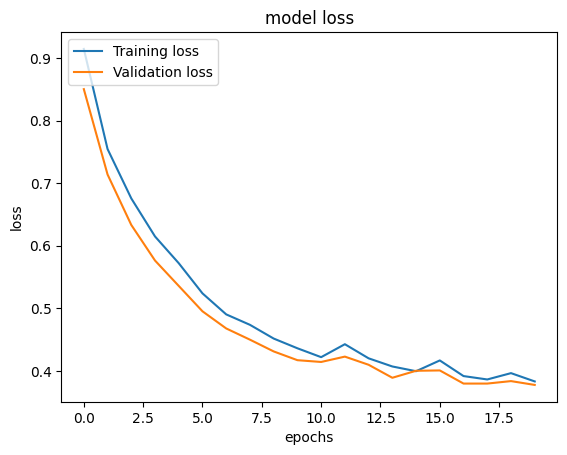

In [30]:
evaluateModel_loss(history_Deep_COVID)

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


--------------------- Teacher Model Evaluation -----------------------------------------
41/41 [==============================] - 34s 737ms/step


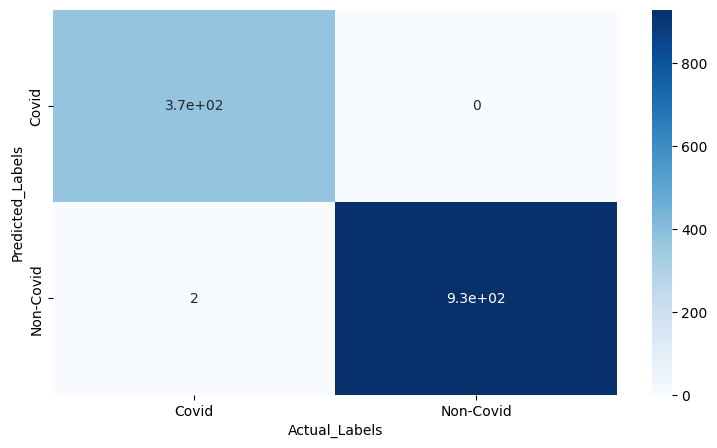

test accuracy = 99.84615384615385%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.9985
Precision: 0.9985
Recall: 0.9985
F1 Score: 0.9985


In [31]:
Deep_COVID_Model_teacher.save('Deep_COVID_teacher_model.h5')
Deep_COVID_Model_teacher = tf.keras.models.load_model('Deep_COVID_teacher_model.h5')
print('--------------------- Teacher Model Evaluation -----------------------------------------')
getModelEvaluation(Deep_COVID_Model_teacher,test_features_dataset2,test_labels_dataset2)

### **Training Teacher Model (CovidVGG16 ($T_3$))**

In [32]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Activation, GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Lambda
input_tensor = Input(shape=(IMAGE_SIZE,IMAGE_SIZE,1))
input_rgb = Lambda(lambda x: K.repeat_elements(x, 3, axis=-1))(input_tensor)

image_size_ = 200
data_augmentation = keras.Sequential(
    [
        tf.keras.layers.Normalization(),
        tf.keras.layers.Resizing(image_size_, image_size_),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor=0.02),
        tf.keras.layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="data_augmentation",
)

def CNN_Mod_VGG16(num_hl, hl_list, hl_conv_activation, ol_activation, dropout_val, inputShape, filters_, kernel_size_, stride_poolSize):
    '''
    CNN_Mod(num_hl, hl_list, hl_conv_activation, ol_activation, dropout_val, inputShape, filters_, kernel_size_, stride_poolSize):
        num_hl = number of hidden layers
        hl_list = list of hidden layer units
        hl_activation = hidden layer activation function
        out_activation = output layer activation function
        dropout_val = Dropout value
        inputShape = shape of input layer
        filters_ = filter size of Conv layer
        kernel_size_ = size of kernel (x,x)
        strides_poolSize = strides and max_pool_szie
    '''
    assert num_hl == len(hl_list)
    assert num_hl == len(dropout_val)

    inputs = tf.keras.layers.Input(shape=inputShape)
    # Augment data.
    augmented = data_augmentation(inputs)

    # Load EfficientNet as base model
    base_model = VGG16(include_top=False, input_tensor=input_rgb, weights='imagenet')

    # Freeze the base model
    base_model.trainable = False

    # Add custom head
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    for i in range(num_hl):
        x = tf.keras.layers.Dense(units=hl_list[i], activation=hl_conv_activation)(x)
        x = tf.keras.layers.Dropout(dropout_val[i])(x)

    # Output layer
    logits = tf.keras.layers.Dense(units=2, activation=ol_activation)(x)

    # Create the Keras model
    model = tf.keras.Model(inputs=base_model.input, outputs=logits)

    # Compile the model
    model = compile_model(model, 'categorical_crossentropy', 0.001, ['accuracy'])

    return model

def buildModel(model, val_split_size, batch_size_,numEpochs, patience_, monitor_, mode):
  '''
  def buildModel(DNN, val_split_size, batch_size_,numEpochs, patience_, monitor_, mode):
    DNN: DNN which the model
    val_split_size: the validation split)
    batch_size_: batch_size
    numEpochs: number of epochs
    patience_: patience of call back
    monitor_: monitor (objective of callback)
    mode: mode (min, max, auto)
  '''
  history = model.fit(
    train_features_dataset3,
    train_labels_dataset3,
    validation_split = val_split_size,
    batch_size = batch_size_,
    epochs = numEpochs,
    callbacks = [
      tf.keras.callbacks.EarlyStopping(monitor= monitor_,patience=patience_,verbose=1,mode=mode),#monitoring loss mode should be min [---val_acc--]
    ]
    )

  return history



In [33]:
CNN_Mod_VGG16_teacher_model  = CNN_Mod_VGG16( 4, [2756, 1776, 620, 152],'relu','softmax',[0.65,0.00,0.00,0.65],(IMAGE_SIZE,IMAGE_SIZE,1),214,5,3)
CNN_Mod_VGG16_history = buildModel(CNN_Mod_VGG16_teacher_model,0.20,32,100,10, "val_loss", "min")

Epoch 1/100
24/24 [==============================] - 18s 710ms/step - loss: 2.1056 - accuracy: 0.6510 - val_loss: 0.4279 - val_accuracy: 0.7969
Epoch 2/100
24/24 [==============================] - 17s 701ms/step - loss: 0.4917 - accuracy: 0.7643 - val_loss: 0.3422 - val_accuracy: 0.8438
Epoch 3/100
24/24 [==============================] - 17s 705ms/step - loss: 0.4670 - accuracy: 0.8359 - val_loss: 0.2722 - val_accuracy: 0.8854
Epoch 4/100
24/24 [==============================] - 16s 692ms/step - loss: 0.3977 - accuracy: 0.8464 - val_loss: 0.3676 - val_accuracy: 0.8281
Epoch 5/100
24/24 [==============================] - 16s 672ms/step - loss: 0.3742 - accuracy: 0.8529 - val_loss: 0.3500 - val_accuracy: 0.8490
Epoch 6/100
24/24 [==============================] - 17s 701ms/step - loss: 0.3371 - accuracy: 0.8854 - val_loss: 0.2666 - val_accuracy: 0.8802
Epoch 7/100
24/24 [==============================] - 17s 700ms/step - loss: 0.3018 - accuracy: 0.8997 - val_loss: 0.2679 - val_accuracy:

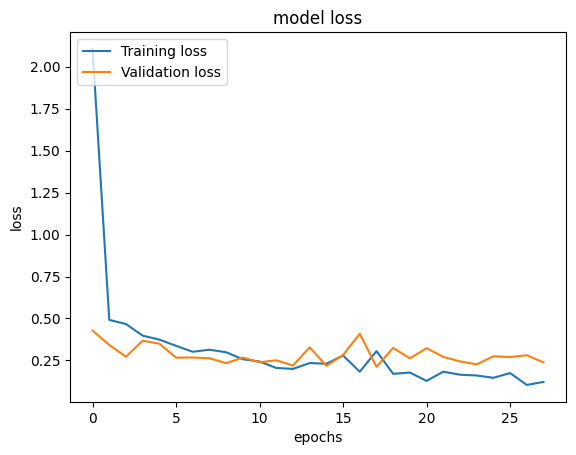

In [34]:
evaluateModel_loss(CNN_Mod_VGG16_history)

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


--------------------- Teacher Model Evaluation -----------------------------------------
8/8 [==============================] - 4s 511ms/step


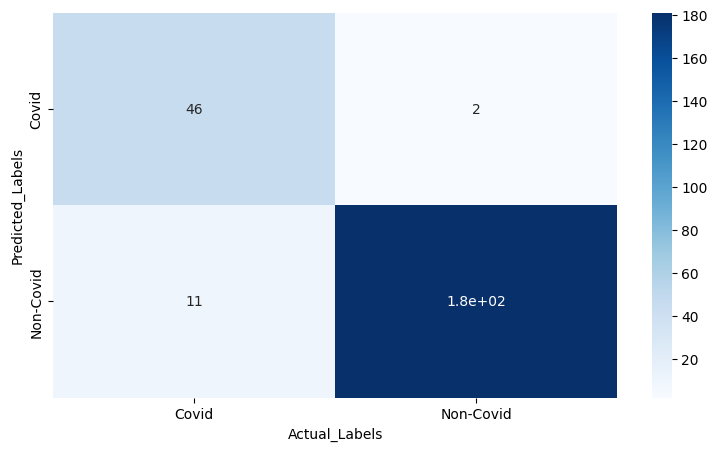

test accuracy = 94.58333333333333%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.9458
Precision: 0.9464
Recall: 0.9458
F1 Score: 0.9442


In [35]:
CNN_Mod_VGG16_teacher_model.save('CNN_Mod_VGG16_teacher_model.h5')
CNN_Mod_VGG16_teacher_model = tf.keras.models.load_model('CNN_Mod_VGG16_teacher_model.h5')
#DCD_Model_teacher.save_weights('DCD_teacher_model_weigth.h5')
print('--------------------- Teacher Model Evaluation -----------------------------------------')
getModelEvaluation(CNN_Mod_VGG16_teacher_model,test_features_dataset3,test_labels_dataset3)

### **Desserminating Knowledge to Student Models ($S_1, S_2 and S_3$) from their respective teachers ($T_1, T_2 and T_3$) via Knowledge distillation**

In [36]:
import tensorflow as tf
from tqdm import tqdm
import time

class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        """Configure the distiller.

        Args:
            optimizer: Keras optimizer for the student weights
            metrics: Keras metrics for evaluation
            student_loss_fn: Loss function of difference between student
                predictions and ground-truth
            distillation_loss_fn: Loss function of difference between soft
                student predictions and soft teacher predictions
            alpha: weight to student_loss_fn and 1-alpha to distillation_loss_fn
            temperature: Temperature for softening probability distributions.
                Larger temperature gives softer distributions.
        """
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def distill(self, train_dataset, epochs,num_steps_per_epoch):
        # Define optimizer
        optimizer = self.optimizer

        # Training loop
        for epoch in range(epochs):
            #print(f"Epoch {epoch + 1}/{epochs}")
            epoch_loss_avg = tf.keras.metrics.Mean()

            # Iterate over the dataset
            for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
            #for x, y in train_dataset:
                x, y = x_batch_train, y_batch_train
                x_reshaped = tf.reshape(x, (-1, IMAGE_SIZE, IMAGE_SIZE, 1))
                with tf.GradientTape() as tape:
                    # Forward pass
                    teacher_pred = self.teacher(x_reshaped, training=False)
                    student_pred = self.student(x_reshaped, training=True)

                    # Reshape y to have the same shape as student_pred
                    y_reshaped = tf.reshape(y, student_pred.shape)

                    # Compute loss
                    #print(y.shape, student_pred.shape)
                    student_loss = self.student_loss_fn(y_reshaped, student_pred)
                    distillation_loss = self.distillation_loss_fn(
                        tf.nn.softmax(teacher_pred / self.temperature, axis=1),
                        tf.nn.softmax(student_pred / self.temperature, axis=1),
                    ) * (self.temperature ** 2)

                    loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
                # Compute gradients and update weights
                gradients = tape.gradient(loss, self.student.trainable_variables)
                optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

                # Update epoch loss
                epoch_loss_avg.update_state(loss)
                if step == num_steps_per_epoch:
                    break;

            # Print epoch results
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss_avg.result()}")

        # Return the student model after distillation process
        return self.student
        def call(self, x, training=False):
            # Forward pass
            return self.student(x, training=training)
def create_keras_model():#this is student model
    initializer = tf.keras.initializers.GlorotNormal(seed=0)
    return tf.keras.models.Sequential([
      #tf.keras.layers.InputLayer(input_shape=(72,72,1)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
      tf.keras.layers.Flatten(),#### Added this march 6 2024
      tf.keras.layers.Dense(2, kernel_initializer=initializer),
      tf.keras.layers.Softmax(),
    ])

#train_features_dataset1, train_labels_dataset1,
def data_generator(x_train, y_train, batch_size):
    num_samples = len(x_train)
    num_batches = num_samples // batch_size
    while True:
        # Shuffle the data for each epoch
        indices = np.random.permutation(num_samples)
        x_shuffled = x_train[indices]
        y_shuffled = y_train[indices]
        for batch_index in range(num_batches):
            start_index = batch_index * batch_size
            end_index = (batch_index + 1) * batch_size
            x_batch = x_shuffled[start_index:end_index]
            y_batch = y_shuffled[start_index:end_index]
            yield x_batch, y_batch

#### **A student model ($S_1$) training using CovidCNN ($T_1$) as a teacher on dataset 1**

In [37]:
student = create_keras_model()
# # Clone student for later comparison
# student_scratch = tf.keras.models.clone_model(student)

teacher_model = tf.keras.models.load_model('teacher_CNN_model.h5')

# Initialize and compile distiller
distiller = Distiller(student=student, teacher=teacher_model)
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
    student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.4,
    temperature=10,
)

In [38]:
batch_size = 128
train_generator = data_generator(train_features_dataset1, train_labels_dataset1,batch_size)
num_steps_per_epoch_ = len(train_features_dataset1) // batch_size

# Distill teacher to student
student_model = distiller.distill(train_generator, epochs=50, num_steps_per_epoch=num_steps_per_epoch_)

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/backend.py:5577: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Epoch 1/50, Loss: 553.0233764648438
Epoch 2/50, Loss: 136.23382568359375
Epoch 3/50, Loss: 44.54170608520508
Epoch 4/50, Loss: 10.581174850463867
Epoch 5/50, Loss: 3.747694730758667
Epoch 6/50, Loss: 1.9439295530319214
Epoch 7/50, Loss: 1.2942869663238525
Epoch 8/50, Loss: 0.683775782585144
Epoch 9/50, Loss: 0.4039869010448456
Epoch 10/50, Loss: 0.36806491017341614
Epoch 11/50, Loss: 0.41667991876602173
Epoch 12/50, Loss: 0.21807190775871277
Epoch 13/50, Loss: 0.09231749922037125
Epoch 14/50, Loss: 0.08882652968168259
Epoch 15/50, Loss: 0.06746593117713928
Epoch 16/50, Loss: 0.09336590021848679
Epoch 17/50, Loss: 0.04236837476491928
Epoch 18/50, Loss: 0.08838775008916855
Epoch 19/50, Loss: 0.0954384058713913
Epoch 20/50, Loss: 0.08824080228805542
Epoch 21/50, Loss: 0.016756761819124222
Epoch 22/50, Loss: 0.01082081999629736
Epoch 23/50, Loss: 0.009314330294728279
Epoch 24/50, Loss: 0.009952881373465061
Epoch 25/50, Loss: 0.006668493151664734
Epoch 26/50, Loss: 0.006469070911407471
Epoc

--------------------- student Model Evaluation -----------------------------------------
 5/16 [========>.....................] - ETA: 0s

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


16/16 [==============================] - 0s 13ms/step


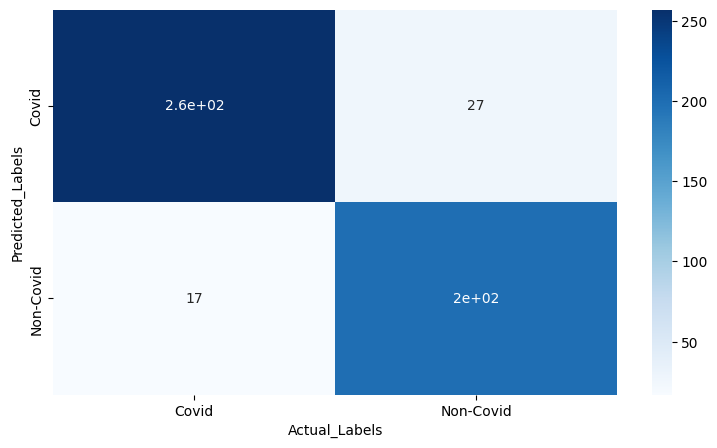

test accuracy = 91.2%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.912
Precision: 0.9123
Recall: 0.912
F1 Score: 0.9118


In [39]:
student_model.save('student_CNN_model.h5')
student_model = tf.keras.models.load_model('student_CNN_model.h5')
print('--------------------- student Model Evaluation -----------------------------------------')
getModelEvaluation(student_model,test_features_dataset1,test_labels_dataset1)

#### **A student model ($S_2$) training using CovidCNN ($T_2$) as a teacher on dataset 2**

In [40]:
student = create_keras_model()
# # Clone student for later comparison
# student_scratch = tf.keras.models.clone_model(student)

teacher_model = tf.keras.models.load_model('Deep_COVID_teacher_model.h5')

# Initialize and compile distiller
distiller = Distiller(student=student, teacher=teacher_model)
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
    student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.4,
    temperature=10,
)

batch_size = 128
train_generator = data_generator(train_features_dataset2, train_labels_dataset2,batch_size)
num_steps_per_epoch_ = len(train_features_dataset1) // batch_size

# Distill teacher to student
student_model = distiller.distill(train_generator, epochs=50, num_steps_per_epoch=num_steps_per_epoch_)

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/backend.py:5577: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Epoch 1/50, Loss: 154.5212860107422
Epoch 2/50, Loss: 11.752267837524414
Epoch 3/50, Loss: 0.9602090716362
Epoch 4/50, Loss: 0.2083972841501236
Epoch 5/50, Loss: 0.17663025856018066
Epoch 6/50, Loss: 0.008455213159322739
Epoch 7/50, Loss: 0.015559901483356953
Epoch 8/50, Loss: 0.01808835007250309
Epoch 9/50, Loss: 0.01727820560336113
Epoch 10/50, Loss: 0.004764901008456945
Epoch 11/50, Loss: 0.00415703933686018
Epoch 12/50, Loss: 0.004423791542649269
Epoch 13/50, Loss: 0.009402994997799397
Epoch 14/50, Loss: 0.02455851063132286
Epoch 15/50, Loss: 0.004484040196985006
Epoch 16/50, Loss: 0.0044433181174099445
Epoch 17/50, Loss: 0.009625562466681004
Epoch 18/50, Loss: 0.004377123899757862
Epoch 19/50, Loss: 0.00444194208830595
Epoch 20/50, Loss: 0.005725015886127949
Epoch 21/50, Loss: 0.022592872381210327
Epoch 22/50, Loss: 0.008202273398637772
Epoch 23/50, Loss: 0.00786497537046671
Epoch 24/50, Loss: 0.004589620977640152
Epoch 25/50, Loss: 0.006920513231307268
Epoch 26/50, Loss: 0.008050

--------------------- student Model Evaluation -----------------------------------------
 1/41 [..............................] - ETA: 2s

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


41/41 [==============================] - 1s 13ms/step


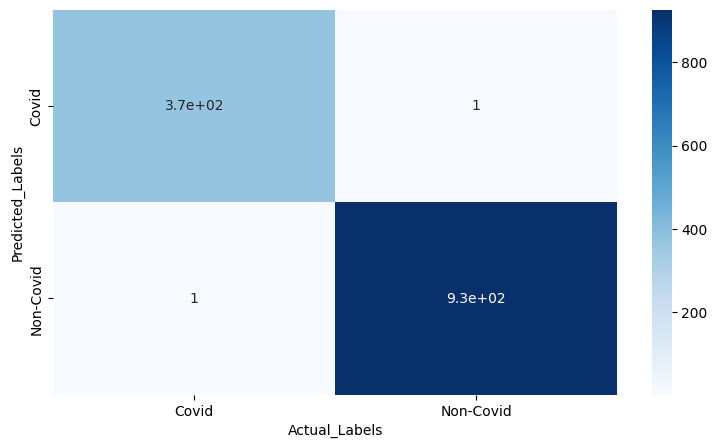

test accuracy = 99.84615384615385%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.9985
Precision: 0.9985
Recall: 0.9985
F1 Score: 0.9985


In [41]:
student_model.save('student_DeepCovid_model.h5')
student_model = tf.keras.models.load_model('student_DeepCovid_model.h5')
print('--------------------- student Model Evaluation -----------------------------------------')
getModelEvaluation(student_model,test_features_dataset2,test_labels_dataset2)

#### **A student model ($S_3$) training using CovidCNN ($T_3$) as a teacher on dataset 3**

In [42]:
student = create_keras_model()
# # Clone student for later comparison
# student_scratch = tf.keras.models.clone_model(student)

teacher_model = tf.keras.models.load_model('CNN_Mod_VGG16_teacher_model.h5')

# Initialize and compile distiller
distiller = Distiller(student=student, teacher=teacher_model)
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
    student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.4,
    temperature=10,
)

batch_size = 128
train_generator = data_generator(train_features_dataset3, train_labels_dataset3,batch_size)
num_steps_per_epoch_ = len(train_features_dataset1) // batch_size

# Distill teacher to student
student_model = distiller.distill(train_generator, epochs=50, num_steps_per_epoch=num_steps_per_epoch_)

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/backend.py:5577: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Epoch 1/50, Loss: 332.8421630859375
Epoch 2/50, Loss: 42.71384811401367
Epoch 3/50, Loss: 13.100237846374512
Epoch 4/50, Loss: 2.206150770187378
Epoch 5/50, Loss: 0.6466561555862427
Epoch 6/50, Loss: 0.40495017170906067
Epoch 7/50, Loss: 0.4368531405925751
Epoch 8/50, Loss: 0.04976576566696167
Epoch 9/50, Loss: 0.01714094914495945
Epoch 10/50, Loss: 0.006940979976207018
Epoch 11/50, Loss: 0.008166234008967876
Epoch 12/50, Loss: 0.007372877094894648
Epoch 13/50, Loss: 0.006690264213830233
Epoch 14/50, Loss: 0.006541738752275705
Epoch 15/50, Loss: 0.0069567314349114895
Epoch 16/50, Loss: 0.0062254685908555984
Epoch 17/50, Loss: 0.006511898245662451
Epoch 18/50, Loss: 0.006643187254667282
Epoch 19/50, Loss: 0.006636080332100391
Epoch 20/50, Loss: 0.00603118073195219
Epoch 21/50, Loss: 0.006933826487511396
Epoch 22/50, Loss: 0.006693873554468155
Epoch 23/50, Loss: 0.005981919355690479
Epoch 24/50, Loss: 0.007405733224004507
Epoch 25/50, Loss: 0.006743485573679209
Epoch 26/50, Loss: 0.00645

--------------------- student Model Evaluation -----------------------------------------
5/8 [=================>............] - ETA: 0s

/home/maxwellsam/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


8/8 [==============================] - 0s 13ms/step


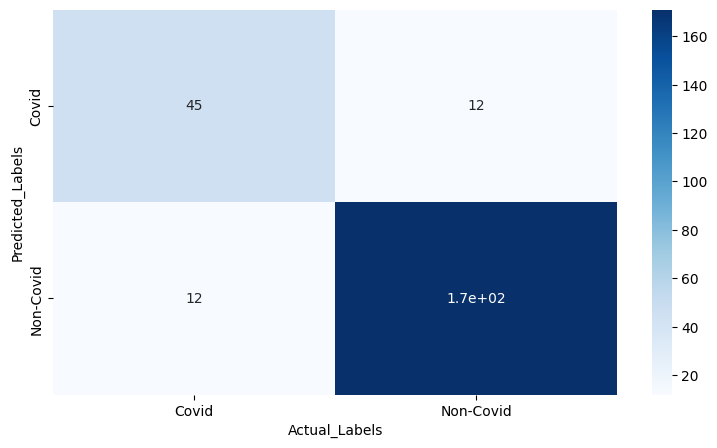

test accuracy = 90.0%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.9
Precision: 0.9
Recall: 0.9
F1 Score: 0.9


In [43]:
student_model.save('student_CovidVGG16_model.h5')
student_model = tf.keras.models.load_model('student_CovidVGG16_model.h5')
print('--------------------- student Model Evaluation -----------------------------------------')
getModelEvaluation(student_model,test_features_dataset3,test_labels_dataset3)